In [6]:
import os
import sys
import math
import random
import time
import scipy
import json
from pathlib import Path
from typing import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import transformers
import xgboost as xgb

import torch
import tensorflow as tf

SEED = 1432

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(SEED)

DEVICE = "mps"

tf.config.set_visible_devices([], "CPU")

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"

for d in [DATA_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

np.set_printoptions(suppress=True, precision=4)

In [7]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import random
from torchvision.transforms import functional as TF

ROOT = Path.cwd()
DATA_ROOT = ROOT / "birds2"

TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"

TRAIN_SKETCH_DIR = TRAIN_DIR / "sketches"
TRAIN_IMAGE_DIR = TRAIN_DIR / "images"

TEST_SKETCH_DIR = TEST_DIR / "sketches"
TEST_IMAGE_DIR = TEST_DIR / "images"

for p in [TRAIN_SKETCH_DIR, TRAIN_IMAGE_DIR, TEST_SKETCH_DIR, TEST_IMAGE_DIR]:
    if not p.exists():
        raise FileNotFoundError(f"Missing: {p}")

IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}


def list_stems(folder: Path):
    stems = []
    for f in folder.iterdir():
        if f.is_file() and f.suffix.lower() in IMG_EXTS:
            stems.append(f.stem)
    return sorted(stems)


def build_pairs(sketch_dir: Path, image_dir: Path):
    s_stems = set(list_stems(sketch_dir))
    i_stems = set(list_stems(image_dir))
    common = sorted(s_stems & i_stems)
    if not common:
        raise ValueError(f"No matched pairs between {sketch_dir} and {image_dir}")
    return common


def find_file_by_stem(folder: Path, stem: str):
    for ext in IMG_EXTS:
        f = folder / f"{stem}{ext}"
        if f.exists():
            return f
    raise FileNotFoundError(f"Missing file for stem={stem} in {folder}")


class PairedSketchImageDataset(Dataset):
    def __init__(
        self,
        root_dir: Path,
        split: str,
        crop_size: int = 256,
        scale_size: int = 286,
        train: bool = True,
        flip: bool = True,
    ):
        self.split = split
        self.crop_size = crop_size
        self.scale_size = scale_size
        self.train = train
        self.flip = flip

        base = root_dir / split
        self.sketch_dir = base / "sketches"
        self.image_dir = base / "images"

        self.stems = build_pairs(self.sketch_dir, self.image_dir)

        self.mean = (0.5, 0.5, 0.5)
        self.std = (0.5, 0.5, 0.5)

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, idx):
        stem = self.stems[idx]
        sketch_path = find_file_by_stem(self.sketch_dir, stem)
        image_path = find_file_by_stem(self.image_dir, stem)

        A = Image.open(sketch_path).convert("RGB")
        B = Image.open(image_path).convert("RGB")

        if self.train:
            A = TF.resize(A, [self.scale_size, self.scale_size], interpolation=TF.InterpolationMode.BICUBIC)
            B = TF.resize(B, [self.scale_size, self.scale_size], interpolation=TF.InterpolationMode.BICUBIC)

            i, j, h, w = transforms.RandomCrop.get_params(A, output_size=(self.crop_size, self.crop_size))
            A = TF.crop(A, i, j, h, w)
            B = TF.crop(B, i, j, h, w)

            if self.flip and random.random() < 0.5:
                A = TF.hflip(A)
                B = TF.hflip(B)
        else:
            A = TF.resize(A, [self.crop_size, self.crop_size], interpolation=TF.InterpolationMode.BICUBIC)
            B = TF.resize(B, [self.crop_size, self.crop_size], interpolation=TF.InterpolationMode.BICUBIC)

        A = TF.normalize(TF.to_tensor(A), self.mean, self.std)
        B = TF.normalize(TF.to_tensor(B), self.mean, self.std)

        return {"A": A, "B": B}


train_ds = PairedSketchImageDataset(DATA_ROOT, "train", crop_size=256, scale_size=286, train=True, flip=True)
test_ds = PairedSketchImageDataset(DATA_ROOT, "test", crop_size=256, scale_size=286, train=False, flip=False)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=0, pin_memory=False)

len(train_ds), len(test_ds)

(10616, 1180)

In [8]:
import torch
import torch.nn as nn

class UNetDown(nn.Module):
    def __init__(self, in_c, out_c, normalize=True):
        super().__init__()
        layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

class UNetUp(nn.Module):
    def __init__(self, in_c, out_c, dropout=0.0):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip):
        x = self.model(x)
        return torch.cat((x, skip), 1)

class GeneratorUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = UNetDown(3, 64, normalize=False)
        self.d2 = UNetDown(64, 128)
        self.d3 = UNetDown(128, 256)
        self.d4 = UNetDown(256, 512)
        self.d5 = UNetDown(512, 512)
        self.d6 = UNetDown(512, 512)
        self.d7 = UNetDown(512, 512)
        self.d8 = UNetDown(512, 512, normalize=False)

        self.u1 = UNetUp(512, 512, 0.5)
        self.u2 = UNetUp(1024, 512, 0.5)
        self.u3 = UNetUp(1024, 512, 0.5)
        self.u4 = UNetUp(1024, 512)
        self.u5 = UNetUp(1024, 256)
        self.u6 = UNetUp(512, 128)
        self.u7 = UNetUp(256, 64)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.d1(x)
        d2 = self.d2(d1)
        d3 = self.d3(d2)
        d4 = self.d4(d3)
        d5 = self.d5(d4)
        d6 = self.d6(d5)
        d7 = self.d7(d6)
        d8 = self.d8(d7)

        u1 = self.u1(d8, d7)
        u2 = self.u2(u1, d6)
        u3 = self.u3(u2, d5)
        u4 = self.u4(u3, d4)
        u5 = self.u5(u4, d3)
        u6 = self.u6(u5, d2)
        u7 = self.u7(u6, d1)

        return self.final(u7)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        def block(in_c, out_c, norm=True):
            layers = [nn.Conv2d(in_c, out_c, 4, 2, 1)]
            if norm:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(6, 64, norm=False),
            *block(64, 128),
            *block(128, 256),
            *block(256, 512),
            nn.Conv2d(512, 1, 4, 1, 1)
        )

    def forward(self, A, B):
        x = torch.cat((A, B), 1)
        return self.model(x)

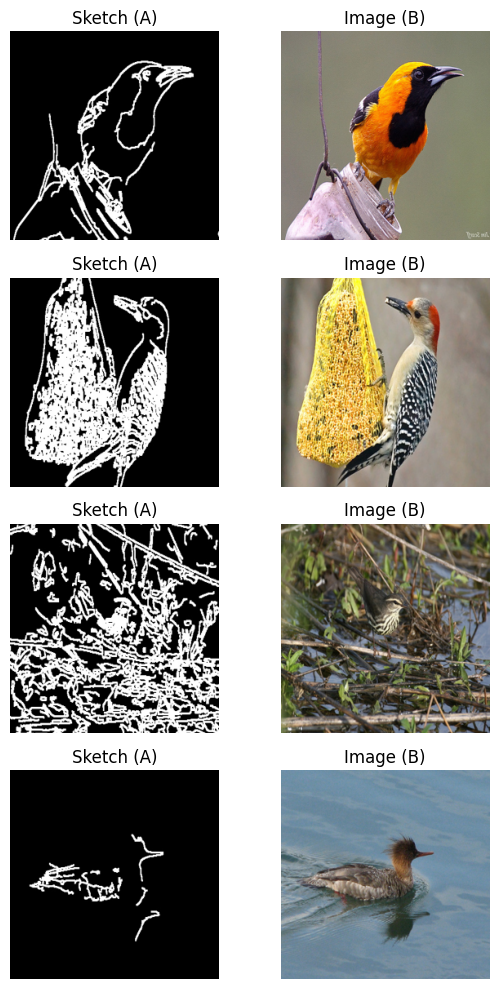

In [9]:
def denorm(x):
    return (x * 0.5 + 0.5).clamp(0, 1)

batch = next(iter(train_loader))
A = denorm(batch["A"])
B = denorm(batch["B"])

n = min(4, A.size(0))
fig, axes = plt.subplots(n, 2, figsize=(6, 2.5 * n))
if n == 1:
    axes = np.array([axes])

for i in range(n):
    axes[i, 0].imshow(A[i].permute(1, 2, 0).cpu().numpy())
    axes[i, 0].set_title("Sketch (A)")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(B[i].permute(1, 2, 0).cpu().numpy())
    axes[i, 1].set_title("Image (B)")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
exit()
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device("mps")

def init_weights_pix2pix(m, init_gain=0.02):
    cname = m.__class__.__name__
    if hasattr(m, "weight") and ("Conv" in cname or "Linear" in cname):
        nn.init.normal_(m.weight.data, 0.0, init_gain)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0.0)
    if "BatchNorm2d" in cname:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, init_gain)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0.0)

def set_requires_grad(net, requires_grad: bool):
    for p in net.parameters():
        p.requires_grad = requires_grad

G = GeneratorUNet().to(device)
D = Discriminator().to(device)
G.apply(init_weights_pix2pix)
D.apply(init_weights_pix2pix)

criterion_gan = nn.BCEWithLogitsLoss()
criterion_l1 = nn.L1Loss()

LR = 2e-4
BETA1 = 0.5
LAMBDA_L1 = 100.0

opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(BETA1, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=LR, betas=(BETA1, 0.999))

N_EPOCHS = 100
N_EPOCHS_DECAY = 100
EPOCH_COUNT = 1

PRINT_FREQ = 200
DISPLAY_FREQ = 400
SAVE_LATEST_FREQ = 5000
SAVE_EPOCH_FREQ = 5

EVAL_BATCHES = 5

OUT_PATH = MODEL_DIR / "pix2pix_birds2.pt"
BEST_PATH = MODEL_DIR / "pix2pix_birds2_best.pt"

PATIENCE = 7
MIN_DELTA = 1e-4

PLOT_EVERY_EPOCH = 1
PRINT_POINTS_ON_PLOT = True

def denorm(x):
    return (x * 0.5 + 0.5).clamp(0, 1)

def _targets_like(pred, is_real: bool):
    return torch.ones_like(pred) if is_real else torch.zeros_like(pred)

def lr_factor(epoch_index: int):
    e = epoch_index + EPOCH_COUNT
    d = e - N_EPOCHS
    if d <= 0:
        return 1.0
    return 1.0 - min(d, N_EPOCHS_DECAY) / float(N_EPOCHS_DECAY + 1)

def update_lr(epoch_index: int):
    f = lr_factor(epoch_index)
    for pg in opt_G.param_groups:
        pg["lr"] = LR * f
    for pg in opt_D.param_groups:
        pg["lr"] = LR * f
    return LR * f

def save_checkpoint(path: Path, step: int, epoch: int):
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "step": step,
            "epoch": epoch,
            "G": G.state_dict(),
            "D": D.state_dict(),
            "opt_G": opt_G.state_dict(),
            "opt_D": opt_D.state_dict(),
            "seed": SEED,
            "lambda_l1": LAMBDA_L1,
            "lr": LR,
            "beta1": BETA1,
            "n_epochs": N_EPOCHS,
            "n_epochs_decay": N_EPOCHS_DECAY,
            "epoch_count": EPOCH_COUNT,
        },
        str(path),
    )

@torch.no_grad()
def mean_l1(loader, max_batches=EVAL_BATCHES):
    G.eval()
    total = 0.0
    n = 0
    for i, batch in enumerate(loader):
        if i >= max_batches:
            break
        real_A = batch["A"].to(device)
        real_B = batch["B"].to(device)
        fake_B = G(real_A)
        total += torch.mean(torch.abs(fake_B - real_B)).item()
        n += 1
    G.train()
    return total / max(n, 1)

@torch.no_grad()
def mean_train_losses(loader, max_batches=EVAL_BATCHES):
    G.eval()
    D.eval()
    total_D = 0.0
    total_G = 0.0
    total_G_gan = 0.0
    total_G_l1 = 0.0
    n = 0

    for i, batch in enumerate(loader):
        if i >= max_batches:
            break

        real_A = batch["A"].to(device)
        real_B = batch["B"].to(device)
        fake_B = G(real_A)

        pred_fake = D(real_A, fake_B)
        loss_G_gan = criterion_gan(pred_fake, _targets_like(pred_fake, True))
        loss_G_l1 = criterion_l1(fake_B, real_B) * LAMBDA_L1
        loss_G = loss_G_gan + loss_G_l1

        pred_fake_D = D(real_A, fake_B.detach())
        loss_D_fake = criterion_gan(pred_fake_D, _targets_like(pred_fake_D, False))
        pred_real_D = D(real_A, real_B)
        loss_D_real = criterion_gan(pred_real_D, _targets_like(pred_real_D, True))
        loss_D = 0.5 * (loss_D_fake + loss_D_real)

        total_D += float(loss_D.item())
        total_G += float(loss_G.item())
        total_G_gan += float(loss_G_gan.item())
        total_G_l1 += float(loss_G_l1.item())
        n += 1

    G.train()
    D.train()

    denom = max(n, 1)
    return total_D / denom, total_G / denom, total_G_gan / denom, total_G_l1 / denom

@torch.no_grad()
def preview_mixed(train_loader, test_loader, n_test=3):
    G.eval()

    train_batch = next(iter(train_loader))
    test_batch = next(iter(test_loader))

    idx_train = int(torch.randint(0, train_batch["A"].shape[0], (1,)).item())
    idx_tests = torch.randint(0, test_batch["A"].shape[0], (min(n_test, test_batch["A"].shape[0]),))

    def get_triplet(batch, idx):
        A = batch["A"][idx:idx+1].to(device)
        B = batch["B"][idx:idx+1].to(device)
        F = G(A)
        return denorm(A).cpu()[0], denorm(F).cpu()[0], denorm(B).cpu()[0]

    triplets = []
    triplets.append(("train", idx_train, *get_triplet(train_batch, idx_train)))

    for k, idx in enumerate(idx_tests.tolist()):
        triplets.append((f"test{k+1}", idx, *get_triplet(test_batch, idx)))

    rows = len(triplets)
    fig, axes = plt.subplots(rows, 3, figsize=(9, 3 * rows))
    if rows == 1:
        axes = np.array([axes])

    for r, (tag, idx, A, F, B) in enumerate(triplets):
        axes[r, 0].imshow(A.permute(1, 2, 0).numpy())
        axes[r, 0].set_title(f"{tag} sketch")
        axes[r, 0].axis("off")

        axes[r, 1].imshow(F.permute(1, 2, 0).numpy())
        axes[r, 1].set_title(f"{tag} generated")
        axes[r, 1].axis("off")

        axes[r, 2].imshow(B.permute(1, 2, 0).numpy())
        axes[r, 2].set_title(f"{tag} target")
        axes[r, 2].axis("off")

    plt.tight_layout()
    plt.show()
    G.train()

def train_step(batch):
    real_A = batch["A"].to(device)
    real_B = batch["B"].to(device)

    fake_B = G(real_A)

    set_requires_grad(D, True)
    opt_D.zero_grad(set_to_none=True)

    pred_fake = D(real_A, fake_B.detach())
    loss_D_fake = criterion_gan(pred_fake, _targets_like(pred_fake, False))

    pred_real = D(real_A, real_B)
    loss_D_real = criterion_gan(pred_real, _targets_like(pred_real, True))

    loss_D = 0.5 * (loss_D_fake + loss_D_real)
    loss_D.backward()
    opt_D.step()

    set_requires_grad(D, False)
    opt_G.zero_grad(set_to_none=True)

    pred_fake_for_G = D(real_A, fake_B)
    loss_G_gan = criterion_gan(pred_fake_for_G, _targets_like(pred_fake_for_G, True))
    loss_G_l1 = criterion_l1(fake_B, real_B) * LAMBDA_L1
    loss_G = loss_G_gan + loss_G_l1
    loss_G.backward()
    opt_G.step()

    return loss_D.detach(), loss_G.detach(), loss_G_gan.detach(), loss_G_l1.detach()

def plot_and_print_points(steps_hist, train_vals, test_vals, ylabel, title):
    plt.figure(figsize=(6, 4))
    plt.plot(steps_hist, train_vals, label=f"train {ylabel}")
    plt.plot(steps_hist, test_vals, label=f"val {ylabel}")
    plt.xlabel("step")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    if PRINT_POINTS_ON_PLOT:
        print("steps:", [int(x) for x in steps_hist])
        print("train:", [float(f"{x:.6f}") for x in train_vals])
        print("val:", [float(f"{x:.6f}") for x in test_vals])

steps_hist = []
train_l1_hist = []
test_l1_hist = []

train_lossD_hist = []
val_lossD_hist = []
train_lossG_hist = []
val_lossG_hist = []
train_lossGgan_hist = []
val_lossGgan_hist = []
train_lossGl1_hist = []
val_lossGl1_hist = []

ema = {"D": None, "G": None, "G_gan": None, "G_l1": None}
EMA_DECAY = 0.95

def update_ema(vals):
    for k, v in vals.items():
        if ema[k] is None:
            ema[k] = v
        else:
            ema[k] = EMA_DECAY * ema[k] + (1.0 - EMA_DECAY) * v

start = time.time()
global_step = 0

best_te = None
epochs_no_improve = 0

total_epochs = N_EPOCHS + N_EPOCHS_DECAY

for epoch_index in range(total_epochs):
    lr_now = update_lr(epoch_index)

    for batch in train_loader:
        lD, lG, lGgan, lGl1 = train_step(batch)
        global_step += 1

        update_ema(
            {
                "D": float(lD.item()),
                "G": float(lG.item()),
                "G_gan": float(lGgan.item()),
                "G_l1": float(lGl1.item()),
            }
        )

        if global_step % PRINT_FREQ == 0:
            elapsed = time.time() - start
            sps = global_step / max(elapsed, 1e-6)
            print(
                f"epoch {epoch_index + EPOCH_COUNT}/{total_epochs} | "
                f"step {global_step} | "
                f"lr {lr_now:.6f} | "
                f"lossD {ema['D']:.3f} | lossG {ema['G']:.3f} | "
                f"G_gan {ema['G_gan']:.3f} | G_l1 {ema['G_l1']:.3f} | "
                f"{sps:.2f} steps/s"
            )

        if global_step % DISPLAY_FREQ == 0:
            preview_mixed(train_loader, test_loader, n_test=3)

        if global_step % SAVE_LATEST_FREQ == 0:
            save_checkpoint(OUT_PATH, step=global_step, epoch=epoch_index + EPOCH_COUNT)

    tr_l1 = mean_l1(train_loader)
    te_l1 = mean_l1(test_loader)

    tr_d, tr_g, tr_ggan, tr_gl1 = mean_train_losses(train_loader)
    te_d, te_g, te_ggan, te_gl1 = mean_train_losses(test_loader)

    steps_hist.append(global_step)
    train_l1_hist.append(tr_l1)
    test_l1_hist.append(te_l1)

    train_lossD_hist.append(tr_d)
    val_lossD_hist.append(te_d)
    train_lossG_hist.append(tr_g)
    val_lossG_hist.append(te_g)
    train_lossGgan_hist.append(tr_ggan)
    val_lossGgan_hist.append(te_ggan)
    train_lossGl1_hist.append(tr_gl1)
    val_lossGl1_hist.append(te_gl1)

    if (epoch_index + EPOCH_COUNT) % PLOT_EVERY_EPOCH == 0:
        plot_and_print_points(steps_hist, train_l1_hist, test_l1_hist, "L1", "Train vs val L1")
        plot_and_print_points(steps_hist, train_lossG_hist, val_lossG_hist, "lossG", "Train vs val lossG")
        plot_and_print_points(steps_hist, train_lossD_hist, val_lossD_hist, "lossD", "Train vs val lossD")

    if best_te is None or te_l1 < best_te - MIN_DELTA:
        best_te = te_l1
        epochs_no_improve = 0
        save_checkpoint(BEST_PATH, step=global_step, epoch=epoch_index + EPOCH_COUNT)
    else:
        epochs_no_improve += 1
        print("didnt improve")

    if (epoch_index + EPOCH_COUNT) % SAVE_EPOCH_FREQ == 0:
        save_checkpoint(OUT_PATH, step=global_step, epoch=epoch_index + EPOCH_COUNT)

    if epochs_no_improve >= PATIENCE:
        print(f"early stop at epoch {epoch_index + EPOCH_COUNT} (best val L1 {best_te:.6f})")
        break

NameError: name 'GeneratorUNet' is not defined

: 